# 06 · Alcance de la lista de contactos: el 70 % que no encuentra
**Proyecto:** Predicción de matrícula y continuidad estudiantil · Unidad Educativa LEMAS
**Integrantes:** Guillermo Granizo y José Ulloa · Maestría en Inteligencia Artificial (UEES)

En la prueba final la regla D2 encontró al 30 % de las familias que no pagaron la matrícula en plazo. La lista tenía más cupos que casos, así que el 70 % restante **no es un problema de capacidad, sino de señal**. Este cuaderno estudia ese 70 % con tres preguntas:

| Pregunta | Sección | Código |
|---|---|---|
| ¿Qué hay dentro de «no pagar en plazo»: familias que pagan tarde o familias que no vuelven? ¿A cuáles encuentra la lista? | 2 | `alcance.desglose_evento` |
| ¿Cuántos casos se alcanzarían con más contactos? | 3 | `alcance.alcance_por_k` |
| ¿Y si la lista se rehace cada semana solo con quienes aún no pagan? | 4 | `alcance.foto_semanal`, `alcance.campana` |

**Reglas que respeta este análisis**
- **C5 no interviene.** Es la cohorte de prueba y ya se evaluó una sola vez.
- **Es descriptivo.** Las cohortes que se usan aquí son las mismas con las que se exploraron los datos y se eligió la regla. Sus cifras ayudan a decidir cómo usar el sistema; no lo validan ni lo cambian.
- **Nada se optimiza.** No se ajusta ninguna regla ni ningún modelo con estos resultados.
- Con datos reales solo se guardan y descargan **agregados**; los conteos menores que 5 se ocultan.

In [1]:
# @title 0 · Preparar el entorno (ejecutar primero)
# Si el repositorio ya está en GitHub con este análisis, pegue su URL; si no, se pedirá el .zip.
REPO_URL = "https://github.com/ggranizo2507/prediccion-matricula-lemas.git"  # @param {type:"string"}

import importlib.util, os, shutil, subprocess, sys, zipfile
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    RAIZ = Path("/content/prediccion-matricula-lemas")
    tiene_analisis = lambda carpeta: (carpeta / "src" / "alcance.py").exists()
    respaldo = Path("/content/base_seud_respaldo.csv")
    if RAIZ.exists() and not tiene_analisis(RAIZ):   # copia anterior, sin este análisis
        for base in RAIZ.rglob("base_seud.csv"):     # no perder la base ya subida
            shutil.copy(base, respaldo)
        shutil.rmtree(RAIZ)
    if not RAIZ.exists() and REPO_URL:
        clon = subprocess.run(["git", "clone", "-q", REPO_URL, str(RAIZ)])
        if clon.returncode != 0 or not tiene_analisis(RAIZ):
            print("GitHub no está disponible o aún no tiene este análisis: se pedirá el .zip.")
            shutil.rmtree(RAIZ, ignore_errors=True)
    if not RAIZ.exists():
        from google.colab import files
        print("Suba el archivo prediccion-matricula-lemas.zip")
        nombre = next(iter(files.upload()))
        zipfile.ZipFile(nombre).extractall("/content")
        if not RAIZ.exists():                        # p. ej. el ZIP descargado de GitHub
            extraidas = [c for c in Path("/content").glob("prediccion-matricula-lemas*")
                         if c.is_dir()]
            if extraidas:
                extraidas[0].rename(RAIZ)
    assert tiene_analisis(RAIZ), "El archivo subido no contiene src/alcance.py: use el zip actualizado."
    if respaldo.exists():
        destino = RAIZ / "data" / "raw" / "base_seud.csv"
        destino.parent.mkdir(parents=True, exist_ok=True)
        if not destino.exists():
            shutil.move(str(respaldo), destino)
else:
    RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))
REQUERIDOS = {'pandas': 'pandas', 'sklearn': 'scikit-learn', 'yaml': 'PyYAML',
              'optuna': 'optuna', 'matplotlib': 'matplotlib'}  # módulo -> paquete pip
faltan = [pip for modulo, pip in REQUERIDOS.items() if importlib.util.find_spec(modulo) is None]
if faltan:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltan], check=True)
print("Entorno:", "Google Colab" if EN_COLAB else "local")

Entorno: local


## 1. Carga de datos y lista de referencia
Se usa la misma base y la misma limpieza que en el resto del proyecto. Con `FUENTE = "real"` se pide `base_seud.csv` (seudonimizada); con `"sintetica"` se usa la base de ejemplo del repositorio.

La unidad es la **familia** (representante). Una familia cuenta como caso si alguno de sus estudiantes no tiene la matrícula pagada al 30 de abril, y sigue **pendiente** hasta que paga el último.

In [2]:
# @title Cargar la base
FUENTE = "sintetica"  # @param ["sintetica", "real"]
# Marque SUBIR_DE_NUEVO si subió un archivo equivocado (se borra y se vuelve a pedir)
SUBIR_DE_NUEVO = False  # @param {type:"boolean"}

import json, logging, warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")
import numpy as np
import pandas as pd
from IPython.display import display
from src import alcance as al
from src import graficos_alcance as ga
from src.data_processing import construir_dataset, limpiar_base
from src.utils import cargar_config, cohortes_desde_config, configurar_logging, obtener_base_seud

configurar_logging(logging.WARNING)
config = cargar_config()
SEMILLA = config["proyecto"]["semilla"]
MIN = config["privacidad"]["min_celda"]
SEMANAS = config["capacidad"]["semanas_campania"]
PERSONAL = sum(config["capacidad"]["personal_por_sede"].values())
MET = RAIZ / config["rutas"]["metricas"]; MET.mkdir(parents=True, exist_ok=True)
FIG = RAIZ / config["rutas"]["figuras"]; FIG.mkdir(parents=True, exist_ok=True)
DPI = config["figuras"]["dpi"]
n = al.numero     # números con coma decimal
ruta = RAIZ / config["rutas"]["base_real" if FUENTE == "real" else "base_sintetica"]

crudo = (obtener_base_seud(ruta, EN_COLAB, SUBIR_DE_NUEVO) if FUENTE == "real"
         else pd.read_csv(ruta, dtype=str))
dataset, _ = construir_dataset(limpiar_base(crudo, config), config)
print(f"Fuente: {FUENTE} | estudiantes modelables: {len(dataset)}")
if FUENTE == "sintetica":
    print("⚠️ Datos SINTÉTICOS: sirven para probar el código, no describen a LEMAS. En "
          "particular, las fechas de pago sintéticas son inventadas.")

Fuente: sintetica | estudiantes modelables: 5715
⚠️ Datos SINTÉTICOS: sirven para probar el código, no describen a LEMAS. En particular, las fechas de pago sintéticas son inventadas.


In [3]:
# @title Cohortes, k y comprobación con la Fase 2 (sin C5)
# Misma decisión sobre C1 y mismo k que en la Fase 2 (results/metrics/decision_c1_*.json)
decision = json.loads((MET / f"decision_c1_{FUENTE}.json").read_text(encoding="utf-8"))
K = decision["k_por_sede"]
ENTRENAMIENTO = config["auditoria"]["configuraciones_entrenamiento"][
    "con_C1" if decision["incluir_C1"] else "sin_C1"]
COHORTES = [*ENTRENAMIENTO, "C4"]
ETIQUETA = f"{COHORTES[0]}–{COHORTES[-1]}"
definiciones = {c.nombre: c for c in cohortes_desde_config(config)}

datos = al.sin_prueba(dataset)
datos = datos[datos["cohorte"].isin(COHORTES)]
assert "C5" not in set(datos["cohorte"])
familias = al.tabla_familias(datos, definiciones)

print(f"Cohortes: {COHORTES} | C5 no se usa | k por sede: {K} | {SEMANAS} semanas | "
      f"personal: {PERSONAL}")
resumen = familias.groupby("cohorte").agg(familias=("evento", "size"), casos=("evento", "sum"))
resumen["tasa"] = (resumen["casos"] / resumen["familias"]).map(lambda v: f"{n(100 * v, 1)} %")
display(resumen)

# La lista de este cuaderno debe ser la misma que se evaluó en C4 en la Fase 2
referencia = pd.read_csv(MET / f"referencias_C4_{FUENTE}.csv").set_index("referencia")
esperado = float(referencia.filter(like="D2", axis=0)["recall_k_C4"].iloc[0])
obtenido = al.desglose_evento(familias, K, SEMILLA).set_index("cohorte").loc["C4", "recall"]
print(f"Recall@k de D2 en C4: Fase 2 = {n(esperado, 4)} | este cuaderno = {n(obtenido, 4)} →",
      "✅ Coincide" if abs(esperado - obtenido) < 5e-4 else "⚠️ No coincide: revisar")

Cohortes: ['C1', 'C2', 'C3', 'C4'] | C5 no se usa | k por sede: {'Mucho Lote 1': 113, 'Mucho Lote 2': 75} | 10 semanas | personal: 10


,familias,casos,tasa
cohorte,,,
C1,932,76,"8,2 %"
C2,977,123,"12,6 %"
C3,1028,84,"8,2 %"
C4,1031,98,"9,5 %"


Recall@k de D2 en C4: Fase 2 = 0,1939 | este cuaderno = 0,1939 → ✅ Coincide


## 2. ¿Qué hay dentro de «no pagar en plazo»?
El evento del proyecto es no tener la matrícula pagada al 30 de abril. Dentro hay tres situaciones distintas:

- **Todos pagan, el último después del 30 de abril.** La familia continúa, pero tarde.
- **Paga por unos estudiantes y no por otros.** Continúa en parte.
- **No registra ningún pago** en el ciclo siguiente. Es lo más cercano a «no vuelve», aunque no es lo mismo: puede haber pagos no registrados.

La señal más fuerte de la regla D2 es haber pagado tarde el año anterior. Si la lista encuentra sobre todo a quienes pagan tarde, está detectando un retraso y no una salida.

,0,1,2,3,4
cohorte,C1,C2,C3,C4,Todas
familias,932,977,1028,1031,3968
eventos,76,123,84,98,381
en_lista,188,188,188,188,752
aciertos,19,30,21,19,89
recall,0.25,0.2439,0.25,0.1939,0.2336
paga tarde,oculto,oculto,oculto,oculto,54
aciertos (paga tarde),oculto,oculto,oculto,oculto,12
recall (paga tarde),NaN,NaN,NaN,NaN,0.2222
% paga tarde,NaN,NaN,NaN,NaN,0.1417


Por cohorte, el detalle por tipo se muestra solo si ninguna celda es menor que 5 
En «Todas» se oculta la celda pequeña y, si es la única, otra más.


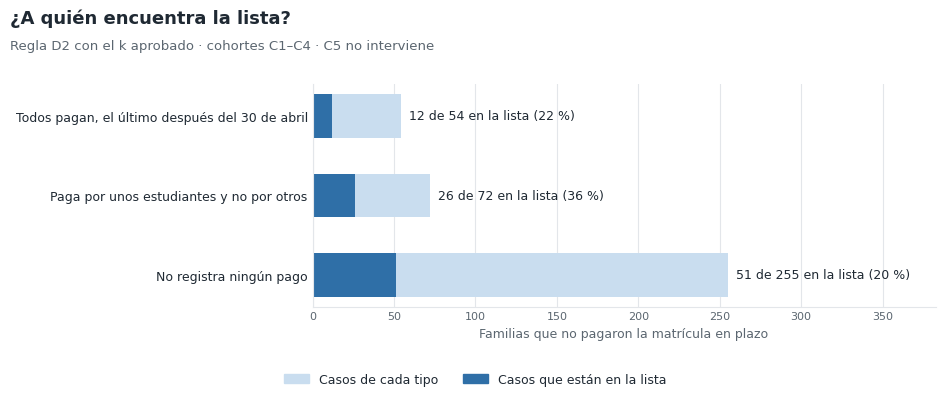

In [4]:
# @title Desglose del evento y aciertos de la lista por tipo
desglose = al.desglose_evento(familias, K, SEMILLA, minimo=MIN)
desglose.to_csv(MET / f"alcance_desglose_{FUENTE}.csv", index=False)
nombres = {"tardia": "paga tarde", "parcial": "paga en parte", "sin_pago": "sin ningún pago"}
titulos = {"mediana_dias_tarde": "mediana de días tarde",
           "pct_tardia_hasta_30_dias": "% que paga en 30 días"}
for tipo, nombre in nombres.items():
    titulos.update({tipo: nombre, f"aciertos_{tipo}": f"aciertos ({nombre})",
                    f"recall_{tipo}": f"recall ({nombre})", f"pct_{tipo}": f"% {nombre}"})
display(desglose.rename(columns=titulos).T)
print("Por cohorte, el detalle por tipo se muestra solo si ninguna celda es menor que", MIN,
      "\nEn «Todas» se oculta la celda pequeña y, si es la única, otra más.")

fig = ga.figura_desglose(desglose, ETIQUETA)
_ = ga.guardar(fig, FIG / f"{FUENTE}_24_alcance_desglose.png", DPI)

## 3. ¿Y con más contactos?
El k aprobado es el doble del promedio histórico de casos por sede. Fue una decisión, no una medida de lo que el personal puede hacer. La tabla muestra qué se alcanzaría con otros tamaños de lista, y cuántos contactos por persona y semana supondría cada uno.

,× k aprobado,contactos,% de familias,aciertos,recall,precision,lift,recall al azar,contactos por persona y semana
4,0.5,380,0.0958,55,0.1444,0.1447,1.5070,0.0958,0.95
9,1.0,752,0.1895,89,0.2336,0.1184,1.2331,0.1895,1.88
14,1.5,1132,0.2853,154,0.4042,0.1360,1.4164,0.2853,2.83
19,2.0,1504,0.3790,188,0.4934,0.1250,1.3018,0.3790,3.76
24,3.0,2256,0.5685,266,0.6982,0.1179,1.2279,0.5685,5.64
29,4.0,3008,0.7581,323,0.8478,0.1074,1.1185,0.7581,7.52
34,todas,3968,1.0000,381,1.0000,0.0960,0.9998,1.0000,9.92


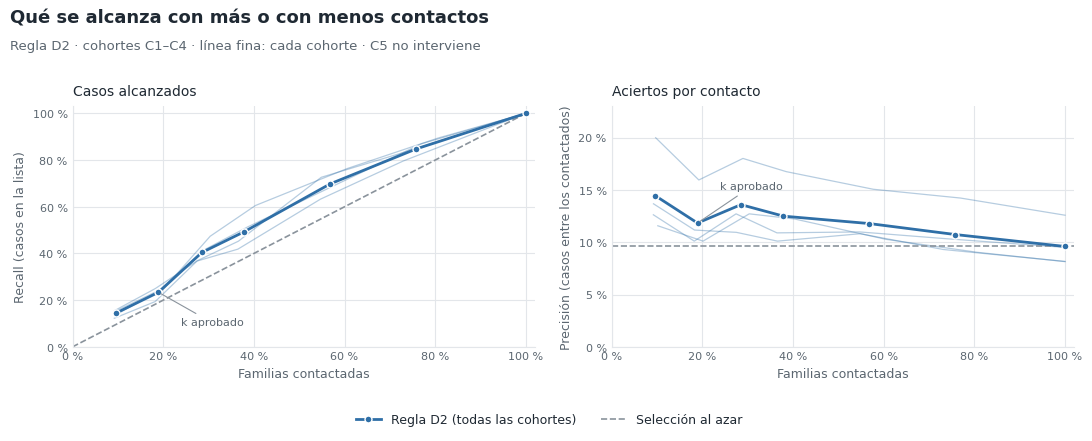

In [5]:
# @title Alcance según el número de contactos
por_k = al.alcance_por_k(familias, K, SEMILLA, personal=PERSONAL, semanas=SEMANAS, minimo=MIN)
por_k.to_csv(MET / f"alcance_por_k_{FUENTE}.csv", index=False)
display(por_k[por_k["cohorte"] == al.TODAS].drop(columns="cohorte").rename(columns={
    "multiplicador": "× k aprobado", "pct_familias": "% de familias",
    "recall_azar": "recall al azar",
    "contactos_por_persona_semana": "contactos por persona y semana"}))

fig = ga.figura_por_k(por_k, ETIQUETA)
_ = ga.guardar(fig, FIG / f"{FUENTE}_25_alcance_por_k.png", DPI)

## 4. ¿Y si la lista se rehace cada semana?
La lista actual es una foto del 20 de febrero. Durante la campaña aparece información que ese día no existe: **quién sigue sin pagar**. No es una variable predictiva: es el resultado, que se va revelando. Quien paga sale del grupo; quien no pagará en plazo se queda hasta el final. Por eso, cerca del 30 de abril, casi todas las familias pendientes son casos, con regla o sin ella.

Primero se mira cómo cambia el grupo semana a semana (solo para el conjunto de las cohortes; las semanas en las que pagan menos de 5 familias se ocultan). Después se comparan tres formas de usar los mismos k contactos:

| Estrategia | Qué hace |
|---|---|
| Lista fija, toda en la semana 1 | El mejor caso del diseño actual: todas las llamadas con el margen completo |
| Lista fija, repartida | Se llama en orden durante las 10 semanas y se salta a quien ya pagó; su cupo queda sin usar |
| Lista semanal | Igual, pero el cupo de quien ya pagó pasa a la siguiente familia pendiente del mismo orden |

Las versiones «al azar» separan cuánto se gana solo por saber quién sigue pendiente y cuánto añade la regla.

**Lo que este análisis no puede decir.** Usa las fechas de pago históricas, como si las llamadas no las cambiaran. Y alcanzar un caso en la semana 9 vale menos que alcanzarlo en la 2, porque queda menos tiempo para ayudar. Por eso el total de la lista semanal no se puede comparar sin más con el de la lista fija: hay que mirar también cuántos casos se alcanzan en la primera mitad de las semanas y con qué margen.

,semana,día,pendientes,% pendientes,pendientes por año,× k aprobado,pagarán en plazo,casos entre pendientes,contactos,aciertos,recall,precision,lift,recall al azar,días hasta el 30-abr
0,1,0,3968,1.0000,992,5.28,3587,0.0960,752,89,0.2336,0.1184,1.2331,0.1895,69
1,2,7,2448,0.6169,612,3.26,2067,0.1556,752,150,0.3937,0.1995,1.2818,0.3072,62
2,3,14,1613,0.4065,403,2.14,1232,0.2362,752,209,0.5486,0.2779,1.1765,0.4662,55
3,4,21,1062,0.2676,266,1.41,681,0.3588,752,297,0.7795,0.3949,1.1007,0.7081,48
4,5,28,768,0.1935,192,1.02,387,0.4961,723,361,0.9475,0.4993,1.0065,0.9414,41
5,6,35,598,0.1507,150,0.80,217,0.6371,591,378,0.9921,0.6396,1.0039,0.9883,34
6,7,42,502,0.1265,126,0.67,121,0.7590,502,381,1.0000,0.7590,1.0000,1.0000,27
7,8,49,450,0.1134,112,0.60,69,0.8467,450,381,1.0000,0.8467,1.0000,1.0000,20
8,9,56,415,0.1046,104,0.55,34,0.9181,415,381,1.0000,0.9181,1.0000,1.0000,13
9,10,63,402,0.1013,100,0.53,21,0.9478,402,381,1.0000,0.9478,1.0000,1.0000,6


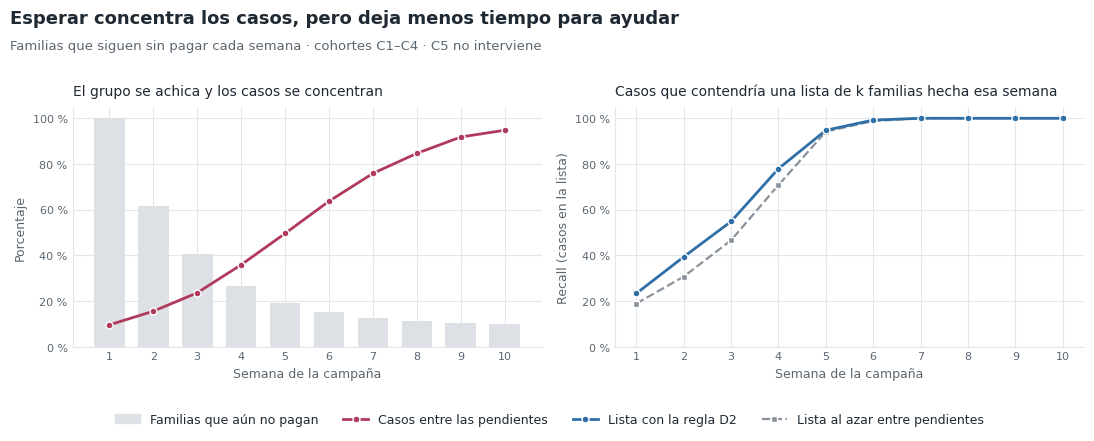

In [6]:
# @title Foto semanal: quién sigue sin pagar
semanal = al.foto_semanal(familias, K, SEMILLA, semanas=SEMANAS, minimo=MIN)
semanal.to_csv(MET / f"alcance_semanal_{FUENTE}.csv", index=False)
display(semanal[semanal["cohorte"] == al.TODAS].drop(columns=["cohorte", "eventos"]).rename(columns={
    "dia": "día", "pct_pendientes": "% pendientes", "pendientes_por_campana": "pendientes por año",
    "veces_k": "× k aprobado", "pagaran_en_plazo": "pagarán en plazo",
    "tasa_base": "casos entre pendientes", "dias_ventana_restante": "días hasta el 30-abr",
    "recall_azar": "recall al azar"}))

fig = ga.figura_semanal(semanal, ETIQUETA)
_ = ga.guardar(fig, FIG / f"{FUENTE}_26_alcance_semanal.png", DPI)

descripcion,"Lista fija, toda en la semana 1 · regla D2","Lista fija, repartida en la campaña · regla D2",Lista semanal · regla D2,"Lista fija, toda en la semana 1 · al azar",Lista semanal · al azar
cupos,752.0000,752.0000,752.0000,752.0000,752.0000
llamadas,752.0000,250.0000,698.0000,752.0000,714.3000
cupos sin usar,0.0000,502.0000,54.0000,0.0000,37.7000
aciertos,89.0000,89.0000,372.0000,71.9000,363.8000
recall,0.2336,0.2336,0.9764,0.1887,0.9549
recall medio (sorteos),0.2329,0.2329,0.9731,0.1887,0.9549
recall mín. (sorteos),0.2205,0.2205,0.9685,0.1470,0.9265
recall máx. (sorteos),0.2441,0.2441,0.9790,0.2572,0.9764
precision,0.1184,0.3560,0.5330,0.0956,0.5093
aciertos en la primera mitad,89.0000,57.0000,124.0000,71.9000,103.4000


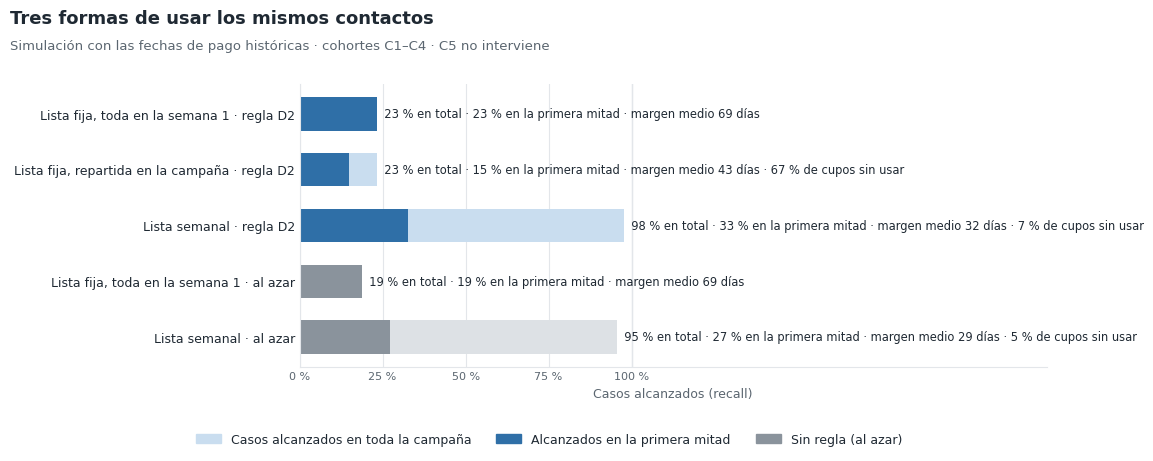

In [7]:
# @title Campaña simulada: lista fija frente a lista semanal
estrategias = al.campana(familias, K, SEMILLA, semanas=SEMANAS, minimo=MIN)
estrategias.to_csv(MET / f"alcance_campana_{FUENTE}.csv", index=False)
display(estrategias[estrategias["cohorte"] == al.TODAS]
        .drop(columns=["cohorte", "estrategia", "eventos"]).set_index("descripcion")
        .rename(columns={"cupos_sin_usar": "cupos sin usar",
                         "recall_medio": "recall medio (sorteos)",
                         "recall_min": "recall mín. (sorteos)", "recall_max": "recall máx. (sorteos)",
                         "aciertos_primera_mitad": "aciertos en la primera mitad",
                         "recall_primera_mitad": "recall en la primera mitad",
                         "margen_medio_dias": "margen medio (días)"}).T)

fig = ga.figura_campana(estrategias, ETIQUETA)
_ = ga.guardar(fig, FIG / f"{FUENTE}_27_alcance_campana.png", DPI)

## 5. Lectura de los resultados
Las frases siguientes se escriben a partir de las cifras de este cuaderno.

In [8]:
# @title Resumen
textos = al.conclusiones(desglose, por_k, semanal, estrategias)
titulos = {"desglose": "Qué hay dentro del evento", "por_k": "Más contactos",
           "semanal": "Quién sigue sin pagar", "campana": "Tres formas de usar los contactos"}
for clave, frases in textos.items():
    print(f"\n{titulos[clave]}")
    for frase in frases:
        print("  •", frase)

total = desglose.set_index("cohorte").loc[al.TODAS]
resumen_json = {"fuente": FUENTE, "cohortes": COHORTES, "k_por_sede": K,
                "familias": int(total["familias"]), "eventos": int(total["eventos"]),
                "semanas": SEMANAS, "personal": PERSONAL,
                "recall_C4_fase2": esperado, "recall_C4_cuaderno": float(obtenido),
                "conclusiones": textos}
(MET / f"alcance_{FUENTE}.json").write_text(
    json.dumps(resumen_json, ensure_ascii=False, indent=2), encoding="utf-8")
if FUENTE == "sintetica":
    print("\n⚠️ Cifras de datos sintéticos: ilustran el método, no son conclusiones sobre LEMAS.")


Qué hay dentro del evento
  • De 381 familias que no pagaron en plazo, 54 (14 %) pagaron todo después del 30 de abril, 72 (19 %) pagaron por unos estudiantes y no por otros y 255 (67 %) no registran ningún pago.
  • La lista alcanza al 22 % de las que pagan tarde, al 36 % de las que pagan en parte y al 20 % de las que no registran ningún pago.
  • Quienes pagan tarde lo hacen a una mediana de 21 días después del 30 de abril; el 70 % paga dentro de los 30 días siguientes.

Más contactos
  • Con el k aprobado se contacta al 19 % de las familias y se alcanza al 23 % de los casos (al azar: 19 %).
  • Con el doble de contactos (38 % de las familias) se alcanza al 49 % (al azar: 38 %); la precisión pasa de 0,118 a 0,125.
  • Con el k aprobado, el Lift de la lista va de 1,06 a 1,37 según la cohorte.
  • Contactar a todas las familias equivale a 9,9 contactos por persona y semana; con el k aprobado son 1,9.

Quién sigue sin pagar
  • En la semana 6 sigue sin pagar el 15 % de las familias, y e

### Cómo leer estos resultados
1. **Con este k, lo que limita es el orden.** La lista tiene más cupos que casos; si la regla ordenara perfectamente, los encontraría todos.
2. **Detectar no es ayudar.** Encontrar a una familia que paga unos días tarde no es lo mismo que encontrar a una que no vuelve, y ninguno de los dos dice si la llamada cambia algo.
3. **Más contactos alcanzan más casos**, pero una lista que cubre a casi todas las familias deja de ser una priorización: ahí lo que importa es el orden y el momento del contacto.
4. **Esperar da información y quita tiempo.** La lista semanal no gasta cupos en quien ya pagó, pero buena parte de lo que gana lo gana tarde, cuando seguir pendiente ya es casi lo mismo que ser un caso.
5. **Nada de esto cambia el sistema validado.** Son hipótesis para la siguiente campaña: cualquier cambio en la forma de usar la lista debe probarse con una cohorte nueva y con un grupo de comparación.

In [9]:
# @title Descargar agregados para compartir (Colab)
# Solo métricas y figuras agregadas: no contiene datos individuales.
paquete = RAIZ / f"alcance_{FUENTE}"
shutil.rmtree(paquete, ignore_errors=True); paquete.mkdir()
for nombre in [f"alcance_desglose_{FUENTE}.csv", f"alcance_por_k_{FUENTE}.csv",
               f"alcance_semanal_{FUENTE}.csv", f"alcance_campana_{FUENTE}.csv",
               f"alcance_{FUENTE}.json"]:
    shutil.copy(MET / nombre, paquete)
for png in sorted(FIG.glob(f"{FUENTE}_2[4-7]_alcance_*.png")):
    shutil.copy(png, paquete)
zip_final = shutil.make_archive(str(paquete), "zip", paquete)
shutil.rmtree(paquete)
print("Contenido:", sorted(zipfile.ZipFile(zip_final).namelist()))
if EN_COLAB:
    from google.colab import files
    files.download(zip_final)

Contenido: ['alcance_campana_sintetica.csv', 'alcance_desglose_sintetica.csv', 'alcance_por_k_sintetica.csv', 'alcance_semanal_sintetica.csv', 'alcance_sintetica.json', 'sintetica_24_alcance_desglose.png', 'sintetica_25_alcance_por_k.png', 'sintetica_26_alcance_semanal.png', 'sintetica_27_alcance_campana.png']
